## Data Preparation

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
# Load the cleaned dataset
file_path = "Data/cleaned_combined_cricket_stats.csv"
df = pd.read_csv(file_path)

In [107]:
df.drop(columns=["Unnamed: 0", 'BF_Test', 'Balls_T20', '4_Test', '10_ODI', '10_T20'], inplace=True)

In [108]:
df.head()

,Player Name,Born,Age,Batting Style,Bowling Style,Playing Role,Innings_ODI_batting,Innings_T20_batting,Innings_Test_batting,NO_ODI,...,T20_Matches,Test_Matches,Country,Current Status,SpanStart_ODI,SpanEnd_ODI,SpanStart_Test,SpanEnd_Test,SpanStart_T20,SpanEnd_T20
0,A Athanaze,12/7/1998,25.643836,Left hand Bat,Right arm Offbreak,Middle order Batter,10,1,13,0,...,1,7,WI,Currently Playing,2023,2024,2023,2024,2024,2024
1,A Balbirnie,12/28/1990,33.586301,Right hand Bat,Right arm Offbreak,Batter,102,106,18,8,...,110,9,IRE,Currently Playing,2010,2024,2018,2024,2015,2024
2,A Dananjaya,10/4/1993,30.819178,Left hand Bat,"Right arm Offbreak, Legbreak",Allrounder,30,16,10,6,...,33,6,SL,Currently Playing,2012,2024,2018,2019,2012,2024
3,A Mishra,11/24/1982,41.679452,Right hand Bat,Legbreak,Bowler,11,1,32,3,...,10,22,IND,Retired,2003,2016,2008,2016,2010,2017
4,A Ndlovu,1/26/1996,28.506849,Right hand Bat,Slow Left arm Orthodox,Bowler,0,5,4,0,...,12,2,ZIM,Currently Playing,2019,2019,2020,2020,2019,2024


#### Getting the Dtype right

In [109]:
# Ensuring numerical cols
numeric_cols = df.columns.drop(['Player Name', 'Born', 'Batting Style', 'Bowling Style', 'Playing Role', 'BBI_ODI','BBI_T20','BBI_Test', 'Country', 'Current Status', 'SpanStart_ODI', 'SpanEnd_ODI', 'SpanStart_Test', 'SpanEnd_Test', 'SpanStart_T20', 'SpanEnd_T20'])
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [110]:
# Ensuring Datetime cols
df["Born"] = df['Born'].apply(pd.to_datetime, errors='coerce')

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 587 entries, 0 to 586
Data columns (total 74 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Player Name           587 non-null    object        
 1   Born                  587 non-null    datetime64[ns]
 2   Age                   587 non-null    float64       
 3   Batting Style         587 non-null    object        
 4   Bowling Style         587 non-null    object        
 5   Playing Role          587 non-null    object        
 6   Innings_ODI_batting   587 non-null    int64         
 7   Innings_T20_batting   587 non-null    int64         
 8   Innings_Test_batting  587 non-null    int64         
 9   NO_ODI                587 non-null    int64         
 10  NO_T20                587 non-null    int64         
 11  NO_Test               587 non-null    int64         
 12  Runs_ODI_batting      587 non-null    int64         
 13  Runs_T20_batting    

#### Feature Engineering

##### Bowling Style

In [112]:
df["Bowling Style"].unique()

array(['Right arm Offbreak', 'Right arm Offbreak, Legbreak', 'Legbreak',
       'Slow Left arm Orthodox', 'Right arm Fast medium',
       'Right arm Fast', 'Right arm Medium, Right arm Offbreak',
       'Right arm Medium', 'Legbreak Googly', 'Left arm Fast medium',
       'Left arm Medium', 'Right arm Medium fast', 'Right arm Slow',
       'Never Bowled', 'Left arm Slow', 'Left arm Wrist spin',
       'Right arm Bowler', 'Left arm Medium fast', 'Left arm Fast',
       'Right arm Offbreak, Slow Left arm Orthodox',
       'Right arm Offbreak, Legbreak Googly',
       'Right arm Medium, Right arm Slow medium',
       'Left arm Fast medium, Slow Left arm Orthodox',
       'Right arm Medium, Legbreak'], dtype=object)

In [113]:
# Define classification rules
def classify_bowling_hand(style):
    if "Left arm" in style:
        return "Left Hand"
    elif "Right arm" in style or "Legbreak" == style or "Legbreak Googly" == style:
        return "Right Hand"
    else:
        return "Unknown"

def classify_bowling_style(style):
    if any(x in style for x in ["Offbreak", "Legbreak", "Orthodox", "Slow", "Wrist spin", "Googly"]):
        return "Spinner"
    elif any(x in style for x in ["Fast", "Medium", "Bowler"]):
        return "Pacer"
    else:
        return "Unknown"

In [114]:
# Apply classification rules
df['Bowling Hand'] = df['Bowling Style'].apply(classify_bowling_hand)
df['Bowling Style'] = df['Bowling Style'].apply(classify_bowling_style)

<Axes: xlabel='count', ylabel='Bowling Hand'>

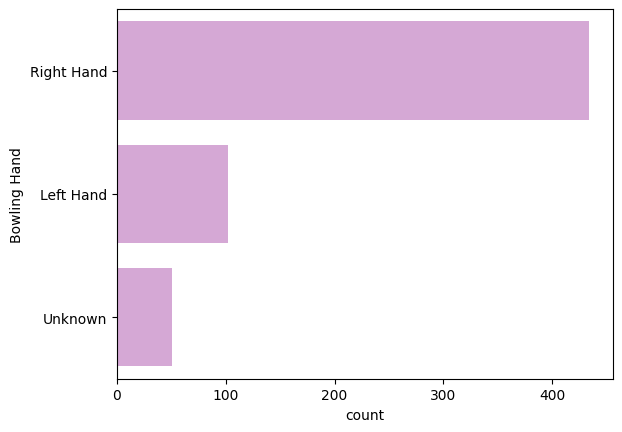

In [115]:
sns.countplot(df['Bowling Hand'], color='plum')

<Axes: xlabel='count', ylabel='Bowling Style'>

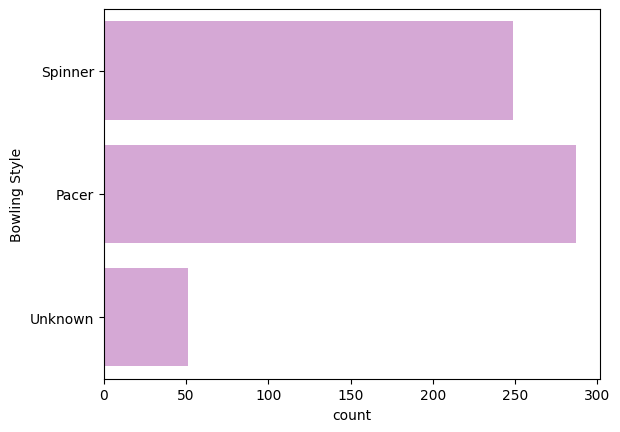

In [116]:
sns.countplot(df['Bowling Style'], color='plum')

##### Playing Role

In [117]:
df["Playing Role"].unique()

array(['Middle order Batter', 'Batter', 'Allrounder', 'Bowler',
       'Opening Batter', 'Top order Batter', 'Bowling Allrounder',
       'Wicketkeeper Batter', 'Batting Allrounder', 'Wicketkeeper'],
      dtype=object)

In [118]:
# Define classification rules
def classify_playing_role(role):
    if 'Batter' in role or 'Wicketkeeper' in role:
        return 'Batter'
    elif 'Allrounder' in role:
        return 'Allrounder'
    elif 'Bowler' in role:
        return 'Bowler'
    else:
        return 'Unknown'

In [119]:
# Apply classification rules
df['Playing Role'] = df['Playing Role'].apply(classify_playing_role)

<Axes: xlabel='count', ylabel='Playing Role'>

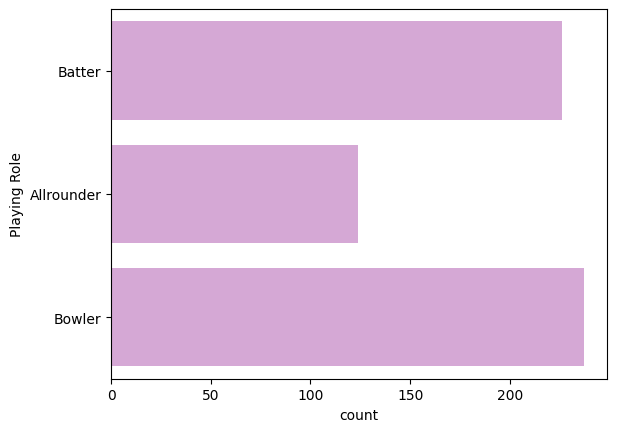

In [120]:
sns.countplot(df['Playing Role'], color='plum')

##### Country

In [121]:
df["Country"].unique()

array(['WI', 'IRE', 'SL', 'IND', 'ZIM', 'SA', 'ENG', 'AUS', 'NZ', 'PAK',
       'BAN', 'AFG', 'ENG/IRE'], dtype=object)

In [122]:
# Define classification rules
def classify_country(country):
    if 'ENG' in country:
        return 'ENG'
    else:
        return country

In [123]:
# Apply classification rule
df['Country'] = df['Country'].apply(classify_country)

<Axes: xlabel='count', ylabel='Country'>

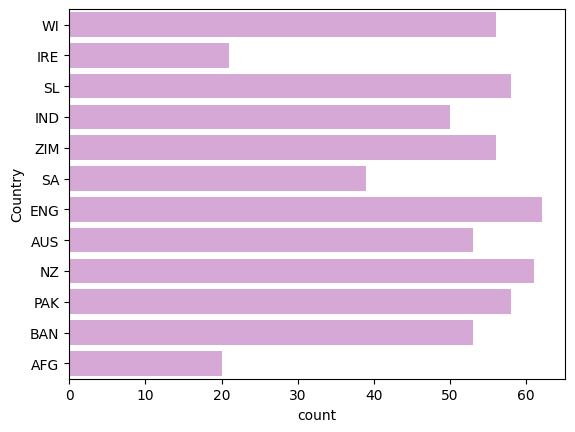

In [124]:
sns.countplot(df['Country'], color='plum')

##### Age

In [125]:
# Current year
current_year = 2024

# Calculate AgeStart for each format
df['AgeStart_ODI'] = df['Age'] - (current_year - df['SpanStart_ODI'])
df['AgeStart_Test'] = df['Age'] - (current_year - df['SpanStart_Test'])
df['AgeStart_T20'] = df['Age'] - (current_year - df['SpanStart_T20'])

In [126]:
df.head()

,Player Name,Born,Age,Batting Style,Bowling Style,Playing Role,Innings_ODI_batting,Innings_T20_batting,Innings_Test_batting,NO_ODI,...,SpanStart_ODI,SpanEnd_ODI,SpanStart_Test,SpanEnd_Test,SpanStart_T20,SpanEnd_T20,Bowling Hand,AgeStart_ODI,AgeStart_Test,AgeStart_T20
0,A Athanaze,1998-12-07,25.643836,Left hand Bat,Spinner,Batter,10,1,13,0,...,2023,2024,2023,2024,2024,2024,Right Hand,24.643836,24.643836,25.643836
1,A Balbirnie,1990-12-28,33.586301,Right hand Bat,Spinner,Batter,102,106,18,8,...,2010,2024,2018,2024,2015,2024,Right Hand,19.586301,27.586301,24.586301
2,A Dananjaya,1993-10-04,30.819178,Left hand Bat,Spinner,Allrounder,30,16,10,6,...,2012,2024,2018,2019,2012,2024,Right Hand,18.819178,24.819178,18.819178
3,A Mishra,1982-11-24,41.679452,Right hand Bat,Spinner,Bowler,11,1,32,3,...,2003,2016,2008,2016,2010,2017,Right Hand,20.679452,25.679452,27.679452
4,A Ndlovu,1996-01-26,28.506849,Right hand Bat,Spinner,Bowler,0,5,4,0,...,2019,2019,2020,2020,2019,2024,Left Hand,23.506849,24.506849,23.506849


In [127]:
df.drop(columns=["Age", 'SpanEnd_ODI', 'SpanEnd_Test', 'SpanEnd_T20', 'Current Status'], inplace=True)

##### BBI

In [128]:
# Define classification rules
def classify_bbi(bbi):
    if bbi == '-':
        return 0
    
    wickets = int(bbi.split('/')[0])
    runs = int(bbi.split('/')[1])

    if runs == 0:
        return 10000

    return wickets/runs


In [129]:
# Calculate BBI Ratio for each format
df['BBI_ODI'] = df['BBI_ODI'].apply(classify_bbi)
df['BBI_T20'] = df['BBI_T20'].apply(classify_bbi)
df['BBI_Test'] = df['BBI_Test'].apply(classify_bbi)

#### Dividing the Dataset

In [130]:
df.head()

,Player Name,Born,Batting Style,Bowling Style,Playing Role,Innings_ODI_batting,Innings_T20_batting,Innings_Test_batting,NO_ODI,NO_T20,...,T20_Matches,Test_Matches,Country,SpanStart_ODI,SpanStart_Test,SpanStart_T20,Bowling Hand,AgeStart_ODI,AgeStart_Test,AgeStart_T20
0,A Athanaze,1998-12-07,Left hand Bat,Spinner,Batter,10,1,13,0,1,...,1,7,WI,2023,2023,2024,Right Hand,24.643836,24.643836,25.643836
1,A Balbirnie,1990-12-28,Right hand Bat,Spinner,Batter,102,106,18,8,4,...,110,9,IRE,2010,2018,2015,Right Hand,19.586301,27.586301,24.586301
2,A Dananjaya,1993-10-04,Left hand Bat,Spinner,Allrounder,30,16,10,6,8,...,33,6,SL,2012,2018,2012,Right Hand,18.819178,24.819178,18.819178
3,A Mishra,1982-11-24,Right hand Bat,Spinner,Bowler,11,1,32,3,0,...,10,22,IND,2003,2008,2010,Right Hand,20.679452,25.679452,27.679452
4,A Ndlovu,1996-01-26,Right hand Bat,Spinner,Bowler,0,5,4,0,3,...,12,2,ZIM,2019,2020,2019,Left Hand,23.506849,24.506849,23.506849


In [133]:
df_batting = df.loc[(df['Playing Role'] == "Batter") | (df['Playing Role'] == "Allrounder")]
df_bowler = df.loc[(df['Playing Role'] == "Bowler") | (df['Playing Role'] == "Allrounder")]

In [134]:
df_batting["Playing Role"].unique()

array(['Batter', 'Allrounder'], dtype=object)

In [136]:
df_bowler["Playing Role"].unique()

array(['Allrounder', 'Bowler'], dtype=object)

In [137]:
df_batting.to_csv("Data/Final_Batting.csv", index=False)
df_bowler.to_csv("Data/Final_Bowling.csv", index=False)